## ML MODEL SUMMARIZER - DECISION TREE WITH CLAUDE API INTEGRATION

### 02: Baseline Model Evaluation

==================================================================
#### SECTION 1: IMPORT PACKAGES & DATA LOADING
==================================================================

In [3]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import GridSearchCV, train_test_split, KFold, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


In [4]:
df_model = pd.read_csv('../data/processed_loan_data.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed_loan_data.csv'

In [ ]:
#set the seed for reproducibility across all random operations
seed = 42
np.random.seed(seed)
random.seed(42)

In [ ]:
X = df_model.drop('default_flag', axis=1)  
y = df_model['default_flag']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=seed, stratify=y)

In [ ]:
# test options for classification
num_folds = 10
scoring_1 = 'accuracy'
#scoring ='precision'
#scoring ='recall'
scoring_2 = 'roc_auc'

In [ ]:
# spot check the algorithms
models = []
models.append(('LR', Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=seed))])))
models.append(('LDA', Pipeline([('scaler', StandardScaler()), ('model', LinearDiscriminantAnalysis())])))
models.append(('KNN', Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())])))
models.append(('DT', DecisionTreeClassifier(random_state=seed)))
models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=seed)))
models.append(('XGB', XGBClassifier(eval_metric='logloss', random_state=seed)))
models.append(('LGBM', LGBMClassifier(random_state=seed, verbose=-1)))


In [ ]:

results_acc = []
results_auc = []
names = []

for name, model in models:
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    cv_results = cross_validate(
        model, X_train, y_train,
        cv=kfold,
        scoring={'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},
        n_jobs=-1  # parallelize across CPU cores
    )
    acc = cv_results['test_accuracy']
    auc = cv_results['test_roc_auc']
    results_acc.append(acc)
    results_auc.append(auc)
    names.append(name)
    print(f"{name}: accuracy={acc.mean():.4f} ({acc.std():.4f}) | roc_auc={auc.mean():.4f} ({auc.std():.4f})")

LR: accuracy=0.8349 (0.0012) | roc_auc=0.8985 (0.0009)
LDA: accuracy=0.8383 (0.0009) | roc_auc=0.9004 (0.0009)
KNN: accuracy=0.8530 (0.0010) | roc_auc=0.8600 (0.0009)
DT: accuracy=0.8689 (0.0010) | roc_auc=0.7970 (0.0016)
RF: accuracy=0.8916 (0.0012) | roc_auc=0.9487 (0.0005)
XGB: accuracy=0.9045 (0.0006) | roc_auc=0.9579 (0.0002)
LGBM: accuracy=0.9002 (0.0007) | roc_auc=0.9549 (0.0003)


/var/folders/b6/z2j2f1js49s1rw1gfk04vyp40000gn/T/ipykernel_17021/2628468702.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(results_acc, labels=names)
/var/folders/b6/z2j2f1js49s1rw1gfk04vyp40000gn/T/ipykernel_17021/2628468702.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(results_auc, labels=names)


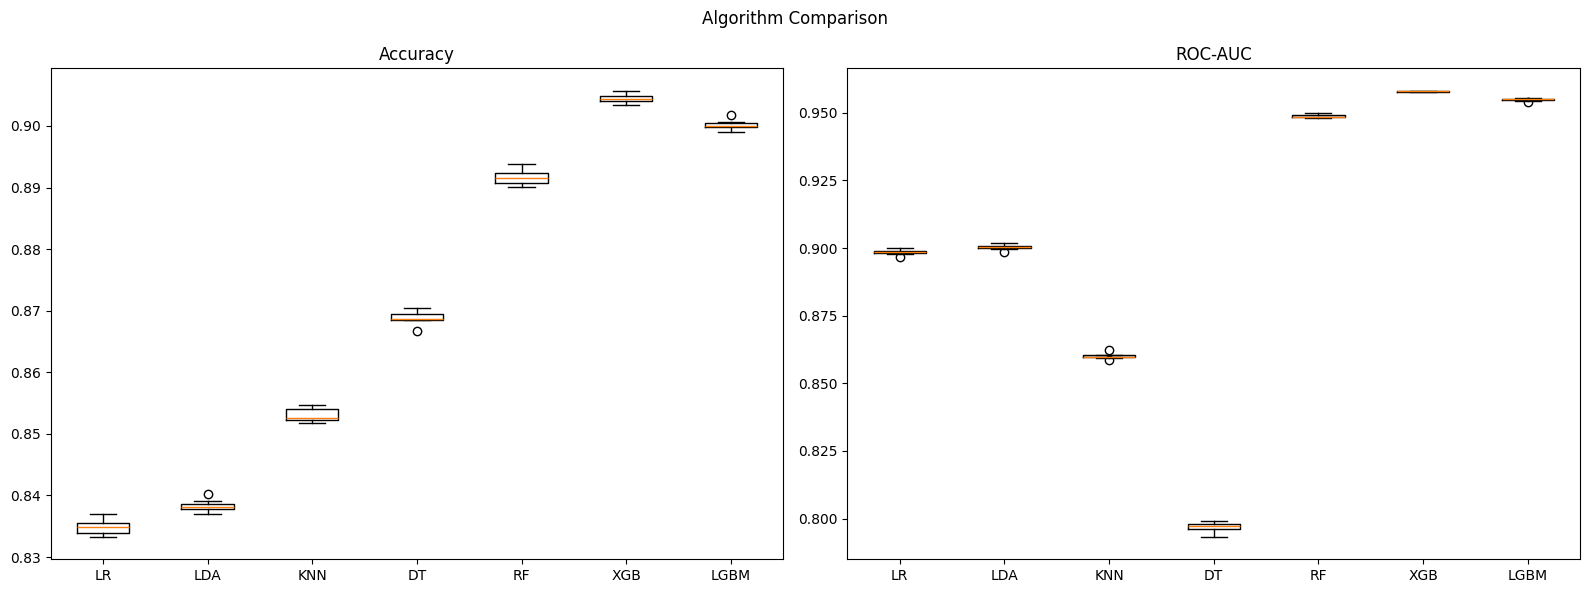

In [ ]:
# compare algorithms
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Algorithm Comparison')

axes[0].boxplot(results_acc, labels=names)
axes[0].set_title('Accuracy')

axes[1].boxplot(results_auc, labels=names)
axes[1].set_title('ROC-AUC')

plt.tight_layout()
plt.show()

In [ ]:
# compare algorithms
fig, axes = plt.subplots(1, 1, figsize=(10, 10))
fig.suptitle('Algorithm Comparison - Scatter')

axes[0].scatter(results_acc.mean(), results_auc.mean())


plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined